# Ejercicio práctica 4: Optimización no lineal con Scipy

Consideremos la función de activación 
$$
\sigma (x) = \max\left\{x, 0\right\}
$$
que, en Machine Learning, es conocida como **ReLU** (Linear Unit Rectifier).
A partir de ella construimos la sencilla red neuronal con dos canales de entrada $(x, y)$ y una sóla neurona
$$
NN(x, y) =  \sigma\left( 2 * x - 3 * y + 1\right)
$$
Se pide:

1) ¿Es diferenciable esta función? ¿Por qué?
2) Define dicha función.


La función **no es diferenciable** cuando 2x-3y+1=0, ya que la función max{x,0}, no es diferenciable en el punto 0, ya que la derivada por la derecha es 1 y la derivada por la izquierda es 0.
En nuestro caso el argumento es 2x-3y+1:
- Si el argumento es mayor que 0, el gradiente es (2, -3)
- Si el argumento es menor que 0, el gradiente es 0

Como las derivadas laterales no coinciden, la función no es derivable en la recta 2x-3y+1=0

In [11]:
import numpy as np
def NN(v):
    x, y = v
    return np.maximum(2*x-3*y+1, 0)

Define ahora la función objetivo siguiente:
$$
MSE ( x, y) = \frac{1}{2} * \left[ (NN(x,y) -1)^2 + (NN(x,y) - 2)^2\right]
$$

In [12]:
def MSE(v):
    return 0.5*((NN(v)-1)**2 + (NN(v)-2)**2)

Dibuja la función $MSE ( x, y)$ en la ventana $-5\leq x\leq 5$, $-5\leq y\leq 5$.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

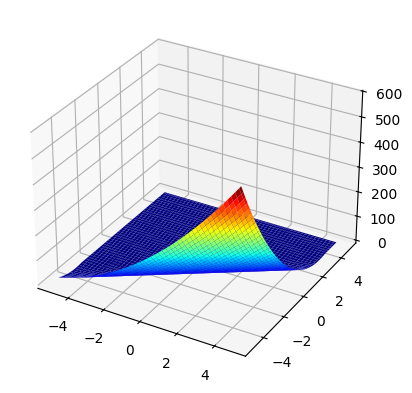

In [14]:
# Completar aquí
r_min = -5.0
r_max = 5.0
xaxis = np.arange(r_min, r_max, 0.1)
yaxis = np.arange(r_min, r_max, 0.1)
x, y = np.meshgrid(xaxis, yaxis)
v = x, y
results = MSE(v)
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_surface(x, y, results, cmap='jet')
plt.show()
# --------------------


Minimiza $MSE ( x, y)$ con el algoritmo de Powell y tomando como punto de inicialización uno elegido aleatoriamente. 

In [15]:
from scipy.optimize import minimize
# Completar aquí
initial_guess = r_min + np.random.rand(2) * (r_max-r_min)
#               num   +  vector_alea_0-1  *    numero
#                 broadcast
result = minimize(MSE, initial_guess, method='powell')
print(f'Estado: {result['message']}')
print(f'número de evaluaciones de la función objetivo: {result['nfev']}')
solution = result['x']
evaluation = MSE(solution)
print(f'Solución f{solution} = {evaluation:.5f}')
# --------------------


Estado: Optimization terminated successfully.
número de evaluaciones de la función objetivo: 84
Solución f[-5.68588593 -3.95725729] = 0.25000
